In [1]:
import sys
import os
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download("vader_lexicon")

sys.path.append(
    os.path.abspath("..")
)



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\megde\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Date Alignment

In [4]:
from scripts.load_data import (
    load_news_data,
    load_stock_data
)
from scripts.alignment import (
    align_news_to_stock_data
    )

In [5]:
df_news = load_news_data()
stocks = load_stock_data()

aligned_data = {}

for name, df_stock in stocks.items():

    aligned_df = align_news_to_stock_data(
        df_news,
        df_stock
    )

    aligned_data[name] = aligned_df

for x,y in aligned_data.items():
    print(x)
    print("")
    display(y[['date','aligned_date']].head())




AAPL



,date,aligned_date
0,2009-02-14,2009-02-17
1,2009-04-27,2009-04-27
2,2009-04-27,2009-04-27
3,2009-04-29,2009-04-29
4,2009-05-22,2009-05-22


AMZN



,date,aligned_date
0,2009-02-14,2009-02-17
1,2009-04-27,2009-04-27
2,2009-04-27,2009-04-27
3,2009-04-29,2009-04-29
4,2009-05-22,2009-05-22


GOOG



,date,aligned_date
0,2009-02-14,2009-02-17
1,2009-04-27,2009-04-27
2,2009-04-27,2009-04-27
3,2009-04-29,2009-04-29
4,2009-05-22,2009-05-22


META



,date,aligned_date
0,2009-02-14,2012-05-18
1,2009-04-27,2012-05-18
2,2009-04-27,2012-05-18
3,2009-04-29,2012-05-18
4,2009-05-22,2012-05-18


NVDA



,date,aligned_date
0,2009-02-14,2009-02-17
1,2009-04-27,2009-04-27
2,2009-04-27,2009-04-27
3,2009-04-29,2009-04-29
4,2009-05-22,2009-05-22


# Sentiment Analysis

In [33]:

sia = SentimentIntensityAnalyzer()
sentences = df_news["headline"].astype(str).tolist()

def analyze_with_vader(sentences):
    sia = SentimentIntensityAnalyzer()
    results = []
    for s in sentences:
        scores = sia.polarity_scores(s)
        compound = scores['compound']
        label = "positive" if compound >= 0.05 else "negative" if compound <= -0.05 else "neutral"
        results.append({
            "sentence": s,
            "compound": compound,
            "pos": scores['pos'],
            "neg": scores['neg'],
            "vader_label": label
        })
    return pd.DataFrame(results)

vader_df = analyze_with_vader(sentences)
vader_df

,sentence,compound,pos,neg,vader_label
0,Stocks That Hit 52-Week Highs On Friday,0.0000,0.000,0.000,neutral
1,Stocks That Hit 52-Week Highs On Wednesday,0.0000,0.000,0.000,neutral
2,71 Biggest Movers From Friday,0.0000,0.000,0.000,neutral
3,46 Stocks Moving In Friday's Mid-Day Session,0.0000,0.000,0.000,neutral
4,B of A Securities Maintains Neutral on Agilent...,0.2960,0.167,0.000,positive
...,...,...,...,...,...
1407323,Top Narrow Based Indexes For August 29,0.2023,0.231,0.000,positive
1407324,Recap: Wednesday's Top Percentage Gainers and ...,-0.3818,0.176,0.333,negative
1407325,UPDATE: Oppenheimer Color on China Zenix Auto ...,0.0000,0.000,0.000,neutral
1407326,Oppenheimer Initiates China Zenix At Outperfor...,0.0000,0.000,0.000,neutral


# Daily Stock Returns

In [40]:
df_news["compound"] = vader_df["compound"].values
df_news["vader_label"] = vader_df["vader_label"].values

In [35]:
daily_returns = {}

for name, df in stocks.items():

    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    df["daily_return"] = df["Close"].pct_change() * 100

    daily_returns[name] = df[["Date", "Close", "daily_return"]]


for x,y in daily_returns.items():
    print(x)
    print("")
    display(y.head())


AAPL



,Date,Close,daily_return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


AMZN



,Date,Close,daily_return
0,2009-01-02,2.718,NaN
1,2009-01-05,2.703,-0.551871
2,2009-01-06,2.868,6.104327
3,2009-01-07,2.810,-2.022318
4,2009-01-08,2.858,1.708189


GOOG



,Date,Close,daily_return
0,2009-01-02,7.948608,NaN
1,2009-01-05,8.115089,2.094467
2,2009-01-06,8.263762,1.832057
3,2009-01-07,7.965677,-3.607137
4,2009-01-08,8.044340,0.987523


META



,Date,Close,daily_return
0,2012-05-18,37.995762,NaN
1,2012-05-21,33.821495,-10.986138
2,2012-05-22,30.810066,-8.903890
3,2012-05-23,31.803938,3.225802
4,2012-05-24,32.827625,3.218744


NVDA



,Date,Close,daily_return
0,2009-01-02,0.199652,NaN
1,2009-01-05,0.203319,1.836972
2,2009-01-06,0.210196,3.382205
3,2009-01-07,0.197589,-5.997831
4,2009-01-08,0.192546,-2.552240


# Aggregation and Correlation

In [47]:
aligned_data = {}

for name, df_stock in stocks.items():

    aligned_df = align_news_to_stock_data(
        df_news,
        df_stock
    )

    aligned_data[name] = aligned_df

daily_sentiment = {}

for name, df in aligned_data.items():

    grouped = (
        df.groupby("aligned_date")["compound"]
        .mean()
        .reset_index()
    )

    grouped.columns = ["Date", "avg_sentiment"]

    daily_sentiment[name] = grouped.dropna()

clean_returns = {}

for name, df in daily_returns.items():
    temp = df.copy()
    temp = temp[["Date", "daily_return"]].dropna()
    clean_returns[name] = temp

for x,y in daily_sentiment.items():
    print(x)
    print("")
    display(y.head())

    


AAPL



,Date,avg_sentiment
0,2009-02-17,0.22630
1,2009-04-27,0.00000
2,2009-04-29,0.00000
3,2009-05-22,0.00000
4,2009-05-27,0.75105


AMZN



,Date,avg_sentiment
0,2009-02-17,0.22630
1,2009-04-27,0.00000
2,2009-04-29,0.00000
3,2009-05-22,0.00000
4,2009-05-27,0.75105


GOOG



,Date,avg_sentiment
0,2009-02-17,0.22630
1,2009-04-27,0.00000
2,2009-04-29,0.00000
3,2009-05-22,0.00000
4,2009-05-27,0.75105


META



,Date,avg_sentiment
0,2012-05-18,0.059971
1,2012-05-21,0.045657
2,2012-05-22,0.074995
3,2012-05-23,0.085223
4,2012-05-24,0.056673


NVDA



,Date,avg_sentiment
0,2009-02-17,0.22630
1,2009-04-27,0.00000
2,2009-04-29,0.00000
3,2009-05-22,0.00000
4,2009-05-27,0.75105


In [48]:
merged_data = {}

for name in stocks.keys():

    merged = pd.merge(
        daily_sentiment[name],
        clean_returns[name],
        on="Date",
        how="inner"
    )

    merged_data[name] = merged

# Pearson correlation

In [50]:
from scipy.stats import pearsonr

correlations = {}

for name, df in merged_data.items():

    corr, _ = pearsonr(
        df["avg_sentiment"],
        df["daily_return"]
    )

    correlations[name] = corr

correlations

{'AAPL': np.float64(0.12597633236646935),
 'AMZN': np.float64(0.07520230944158465),
 'GOOG': np.float64(0.10883117910010336),
 'META': np.float64(0.13796620375704824),
 'NVDA': np.float64(0.10141313075162245)}

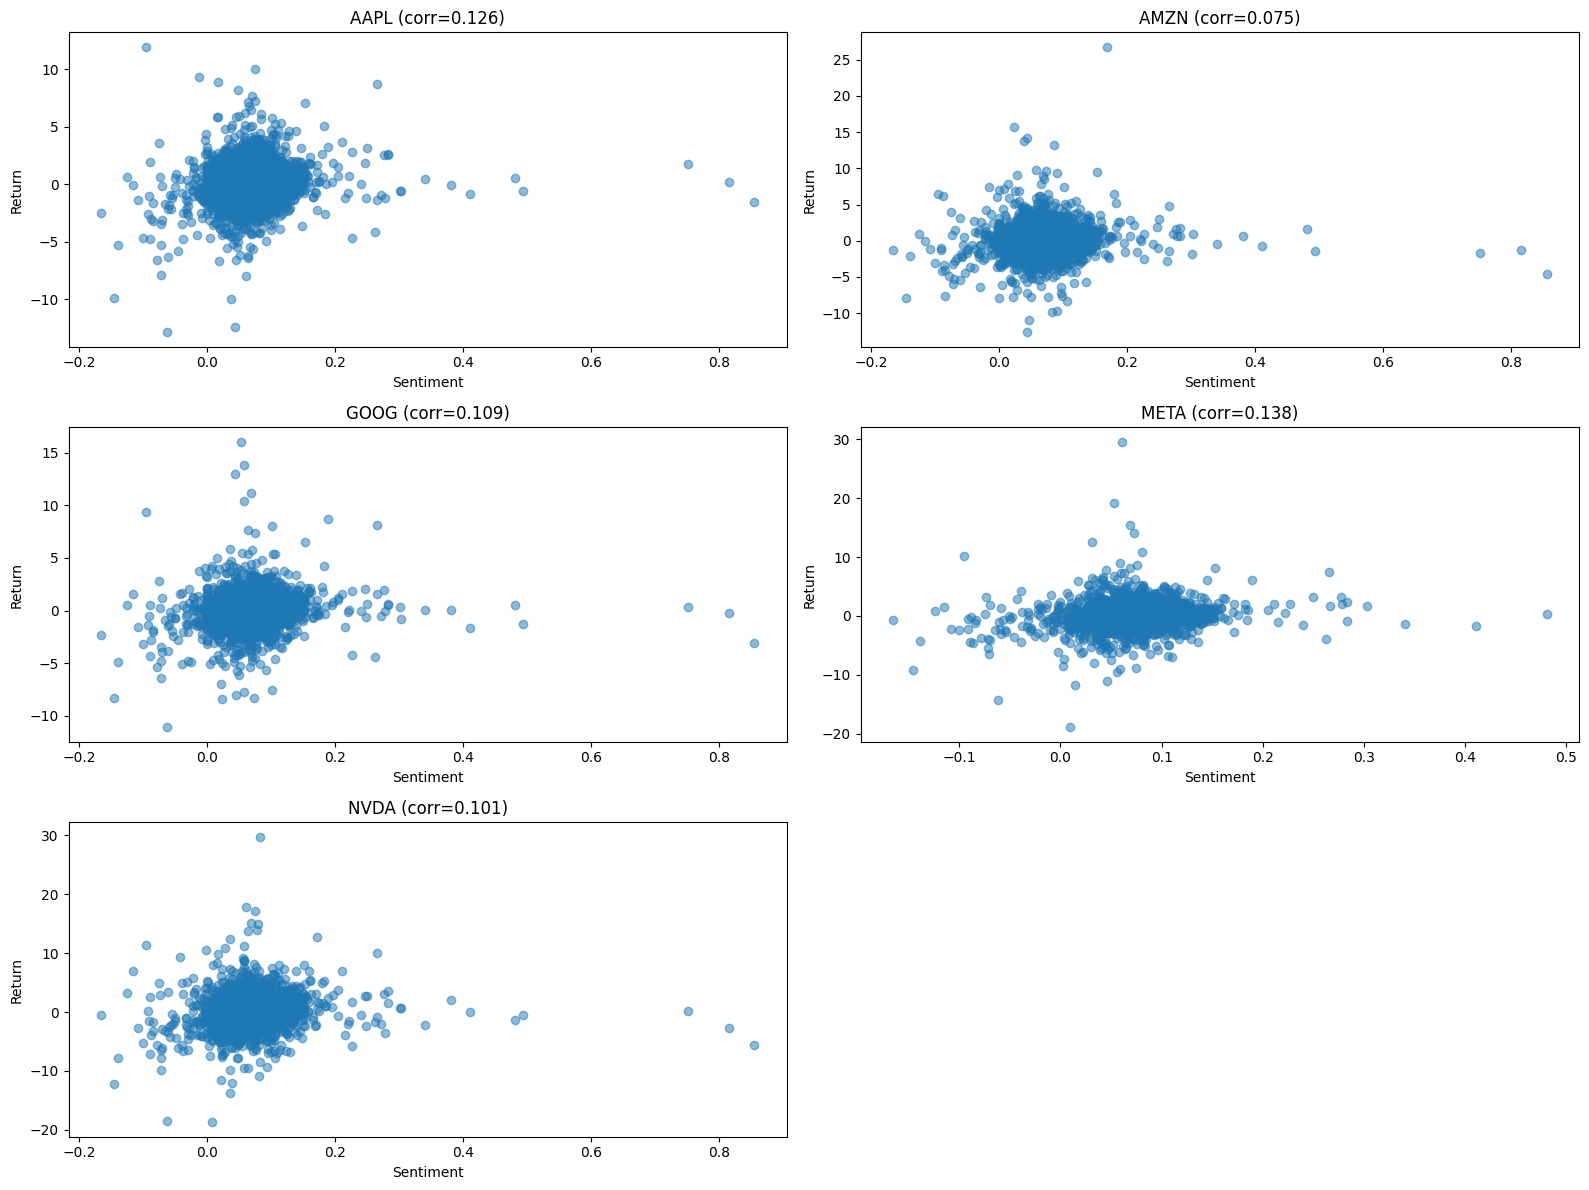

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(merged_data):

    df = merged_data[name]

    axes[i].scatter(
        df["avg_sentiment"],
        df["daily_return"],
        alpha=0.5
    )

    axes[i].set_title(
        f"{name} (corr={correlations[name]:.3f})"
    )

    axes[i].set_xlabel("Sentiment")
    axes[i].set_ylabel("Return")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

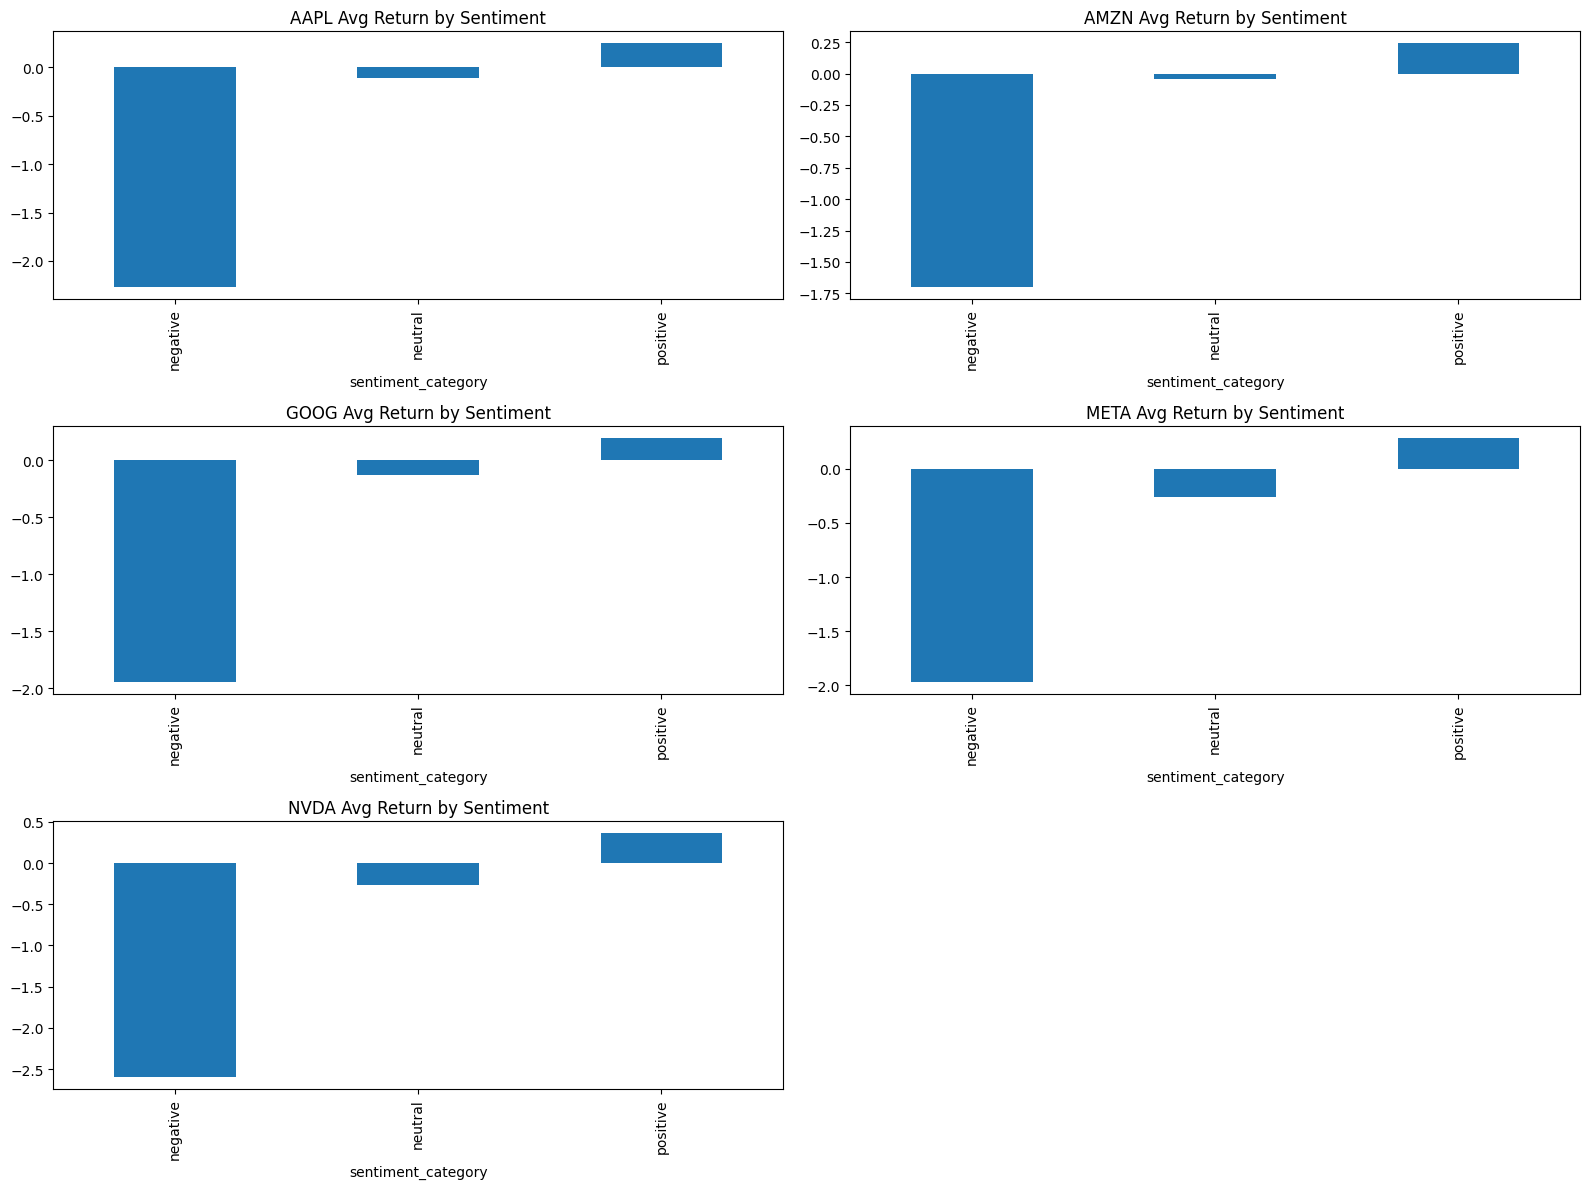

In [53]:
def label_sentiment(x):

    if x >= 0.05:
        return "positive"
    elif x <= -0.05:
        return "negative"
    else:
        return "neutral"

category_results = {}

for name, df in merged_data.items():

    df["sentiment_category"] = df["avg_sentiment"].apply(label_sentiment)

    grouped = df.groupby("sentiment_category")["daily_return"].mean()

    category_results[name] = grouped

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, name in enumerate(category_results):

    category_results[name].plot(
        kind="bar",
        ax=axes[i]
    )

    axes[i].set_title(f"{name} Avg Return by Sentiment")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

# Interpretation of results

The correlations between average daily sentiment and stock returns were generally weak, which suggests that headline sentiment alone is not a strong predictor of short term stock price movement. Some stocks showed slightly positive relationships while others showed little to no correlation.

The bar charts also showed that positive sentiment days sometimes had higher average returns, but the differences were not very large or consistent across all stocks.

One limitation of this approach is that stock prices are influenced by many external factors besides news sentiment, such as broader market conditions, earnings reports and economic events. Another limitation is lag effects, where the market may react hours or days after news is published rather than immediately.

In [54]:
from scipy import stats

significance_results = {}

for name, df in merged_data.items():

    r_val, p_val = stats.pearsonr(
        df["avg_sentiment"],
        df["daily_return"]
    )

    significance_results[name] = {
        "correlation": r_val,
        "p_value": p_val
    }

    print(f"\n{name}")
    print("-" * 40)

    print(f"Correlation: {r_val:.4f}")
    print(f"P-Value: {p_val:.4e}")

    if p_val < 0.05:
        print("Statistically significant")
    else:
        print("Not statistically significant")


AAPL
----------------------------------------
Correlation: 0.1260
P-Value: 3.1002e-11
Statistically significant

AMZN
----------------------------------------
Correlation: 0.0752
P-Value: 7.6657e-05
Statistically significant

GOOG
----------------------------------------
Correlation: 0.1088
P-Value: 9.9274e-09
Statistically significant

META
----------------------------------------
Correlation: 0.1380
P-Value: 4.3578e-10
Statistically significant

NVDA
----------------------------------------
Correlation: 0.1014
P-Value: 9.3375e-08
Statistically significant


I also tested statistical significance using p-values. Most correlations were statistically significant, suggesting that the observed relationships between sentiment and daily returns aren't mostly influenced by random market noise.